# Imports

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from keras.layers import Input, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D
from keras.layers import AveragePooling2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D
from keras.models import Model, Sequential
from IPython.display import Image, display

## Load data

In [57]:
def load_data(train_path, test_path):
    train_data=h5py.File(train_path, "r")
    train_set_x_orig=np.array(train_data["train_set_x"][:])
    train_set_y_orig=np.array(train_data["train_set_y"][:])
    test_data=h5py.File(test_path, "r")
    test_set_x_orig=np.array(test_data["test_set_x"][:])
    test_set_y_orig=np.array(test_data["test_set_y"][:])
    classes=np.array(test_data["classeslist"][:])
    train_set_y_orig=train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig=test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [58]:
train_path='data/train_happyhouse.h5'
test_path='data/test_happyhouse.h5'
with h5py.File(train_path, "r") as train_data:
    X_train_orig = np.array(train_data["train_set_x"][:])
    Y_train_orig = np.array(train_data["train_set_y"][:])

with h5py.File(test_path, "r") as test_data:
    X_test_orig = np.array(test_data["test_set_x"][:])
    Y_test_orig = np.array(test_data["test_set_y"][:])
    classes = np.array(test_data["classes"][:] if "classes" in test_data else test_data["list_classes"][:])

X_train=X_train_orig/255.
X_test=X_test_orig/255.
Y_train=Y_train_orig.T
Y_test=Y_test_orig.T

print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

Number of training examples = 600
Number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600,)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150,)


## First model

In [59]:
def Happy_Model1(input_shape):

    X_input= Input(input_shape)
    X =ZeroPadding2D((3, 3))(X_input)
    X =Conv2D(32, (7, 7), strides = (1, 1), name = 'conv0')(X)
    X =BatchNormalization(axis = 3, name = 'bn0')(X)
    X =Activation('relu')(X)

    X =MaxPooling2D((2, 2), name='max_pool')(X)

    X =Flatten()(X)
    X =Dense(1, activation='sigmoid', name='fc')(X)

    model=Model(inputs = X_input, outputs = X, name='Model 1')

    return model

In [60]:
hmodel1=Happy_Model1(X_train.shape[1:])
hmodel1.compile(optimizer = "Adam", loss = "binary_crossentropy", metrics = ["accuracy"])
hmodel1.summary()

Model: "Model 1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 70, 70, 3)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool (MaxPooling2D)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

In [61]:
def Happy_Model1(input_shape):

    X_input = Input(input_shape)
    X = ZeroPadding2D((3, 3))(X_input)
    X = Conv2D(32, (7, 7), strides=(1, 1), name='conv0')(X)
    X = BatchNormalization(axis=3, name='bn0')(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((2, 2), name='max_pool')(X)
    X = Flatten()(X)
    X = Dense(1, activation='sigmoid', name='fc')(X)

    model = Model(inputs=X_input, outputs=X, name='Model_1')

    return model

K.clear_session()
hmodel1=Happy_Model1(X_train.shape[1:])
hmodel1.compile(optimizer="Adam", loss="binary_crossentropy", metrics=["accuracy"])

history = hmodel1.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, Y_test)
)
preds = hmodel1.evaluate(X_test, Y_test)

print()
print("Loss = " + str(preds[0]))
print("Accuracy of the test = " + str(preds[1]))

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7383 - loss: 1.1468 - val_accuracy: 0.5933 - val_loss: 0.5906
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9300 - loss: 0.1935 - val_accuracy: 0.6267 - val_loss: 0.5268
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9267 - loss: 0.1813 - val_accuracy: 0.7133 - val_loss: 0.5528
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9283 - loss: 0.1713 - val_accuracy: 0.8200 - val_loss: 0.3316
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9517 - loss: 0.1130 - val_accuracy: 0.5667 - val_loss: 1.0999
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9667 - loss: 0.0951 - val_accuracy: 0.8467 - val_loss: 0.3361
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9633 - loss: 0.1025 - val_accuracy: 0.8667 - val_loss: 0.2241
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9533 - loss: 0.1027 - val_accuracy: 0.8933 - v

## Train and validation loses

Text(0.5, 1.0, 'Loss curves')

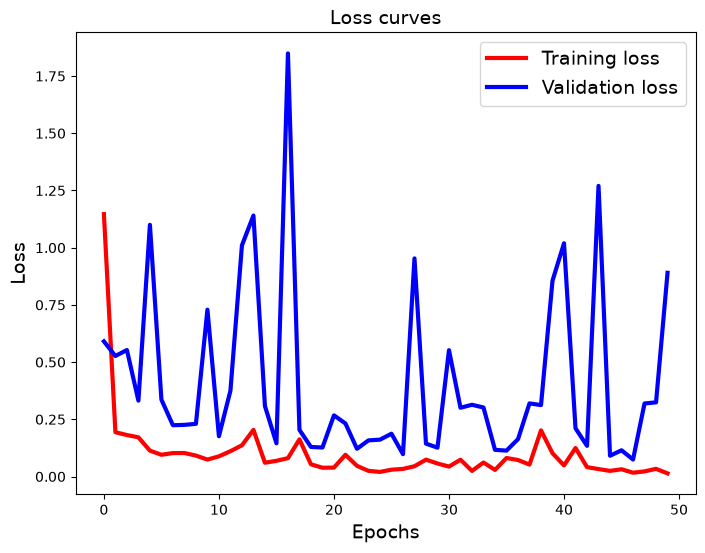

In [62]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.xlabel('Epochs',fontsize=14)
plt.ylabel('Loss',fontsize=14)
plt.legend(['Training loss', 'Validation loss'],fontsize=14)
plt.title('Loss curves',fontsize=14)

## Train and validation accuracies

Text(0.5, 1.0, 'Accuracy curves')

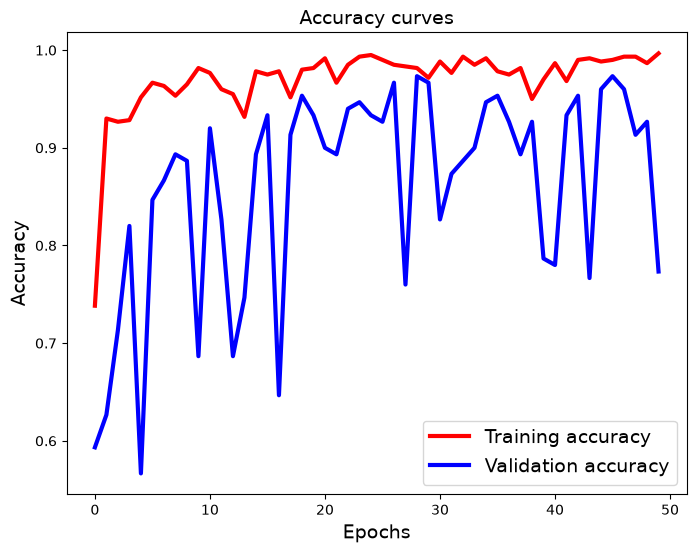

In [63]:
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training accuracy', 'Validation accuracy'],fontsize=14)
plt.xlabel('Epochs',fontsize=14)
plt.ylabel('Accuracy',fontsize=14)
plt.title('Accuracy curves',fontsize=14)

## Visualization of predicts

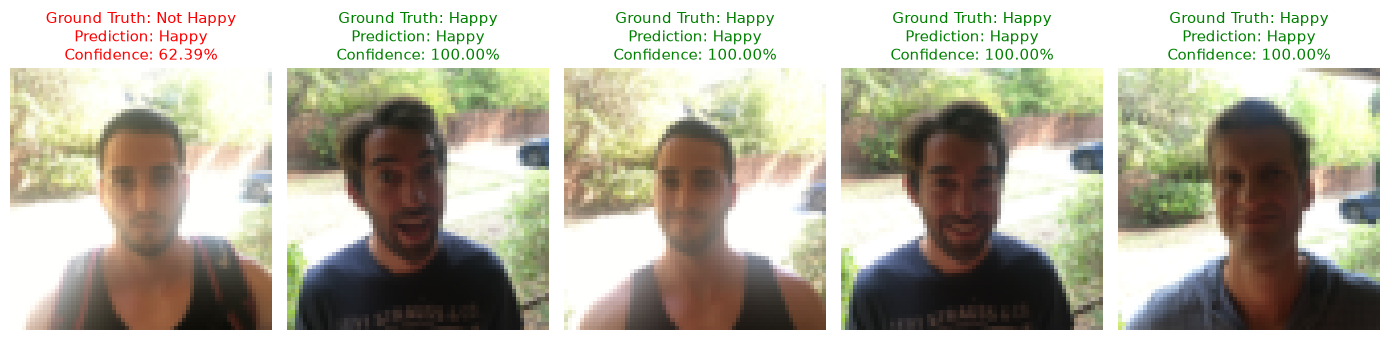

In [64]:
num_samples=5
random_indices=np.random.choice(X_test.shape[0], num_samples, replace=False)

plt.figure(figsize=(14, 5))

for i, idx in enumerate(random_indices):
    img=X_test[idx]
    true_label = int(Y_test[idx])
    img_for_prediction= np.expand_dims(img, axis=0)
    
    pred_prob=hmodel1.predict(img_for_prediction, verbose=0)[0][0]
    pred_label= 1 if pred_prob > 0.5 else 0
    status_true = "Happy" if true_label == 1 else "Not Happy"
    status_pred= "Happy" if pred_label == 1 else "Not Happy"
    title_color= 'green' if true_label == pred_label else 'red'

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"Ground Truth: {status_true}\nPrediction: {status_pred}\nConfidence: {pred_prob:.2%}", 
              color=title_color, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Second model (add dropout and more layers)

In [65]:
def Happy_Model2(input_shape):
    model=Sequential()
    
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    return model

In [66]:
hmodel2=Happy_Model2(X_train.shape[1:])
hmodel2.compile(optimizer = "Adam", loss = "binary_crossentropy", metrics = ["accuracy"])
hmodel2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,097 (5.04 MB)

 Trainable params: 1,320,097 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
history2=hmodel2.fit(X_train, Y_train, epochs = 50, batch_size = 16, validation_data=(X_test, Y_test))
preds2=hmodel2.evaluate(X_test, Y_test)

print()
print("Loss = " + str(preds2[0]))
print("Accuracy of the test = " + str(preds2[1]))

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.5083 - loss: 0.7107 - val_accuracy: 0.5600 - val_loss: 0.6910
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5267 - loss: 0.6920 - val_accuracy: 0.4400 - val_loss: 0.6989
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5567 - loss: 0.6854 - val_accuracy: 0.5600 - val_loss: 0.6928
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5700 - loss: 0.6847 - val_accuracy: 0.5733 - val_loss: 0.6849
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5767 - loss: 0.6532 - val_accuracy: 0.4733 - val_loss: 0.6907
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6250 - loss: 0.6409 - val_accuracy: 0.6600 - val_loss: 0.6115
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.6867 - loss: 0.5799 - val_accuracy: 0.5867 - val_loss: 0.5780
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7833 - loss: 0.4719 - val_accuracy: 0.8000 - v

## Train and validation loses

Text(0.5, 1.0, 'Loss curves')

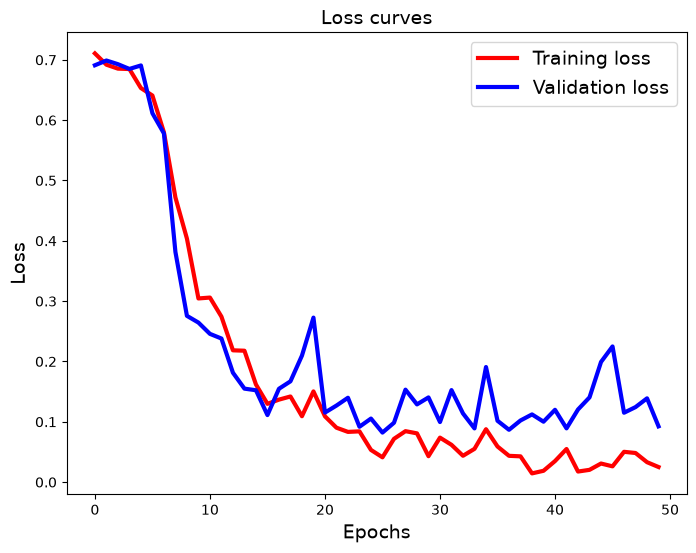

In [68]:
plt.figure(figsize=[8,6])
plt.plot(history2.history['loss'],'r',linewidth=3.0)
plt.plot(history2.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation loss'],fontsize=14)
plt.xlabel('Epochs',fontsize=14)
plt.ylabel('Loss',fontsize=14)
plt.title('Loss curves',fontsize=14)

## Train and validation accuracies

Text(0.5, 1.0, 'Accuracy curves')

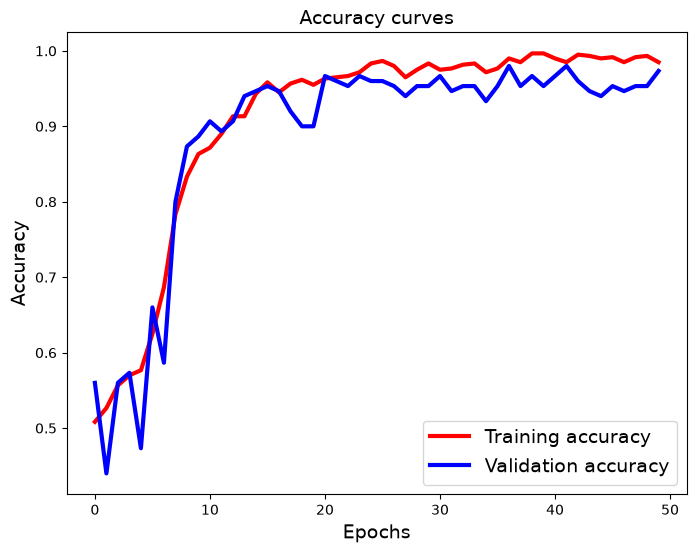

In [69]:
plt.figure(figsize=[8,6])
plt.plot(history2.history['accuracy'],'r',linewidth=3.0)
plt.plot(history2.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training accuracy', 'Validation accuracy'],fontsize=14)
plt.xlabel('Epochs',fontsize=14)
plt.ylabel('Accuracy',fontsize=14)
plt.title('Accuracy curves',fontsize=14)

## Predicts visualization

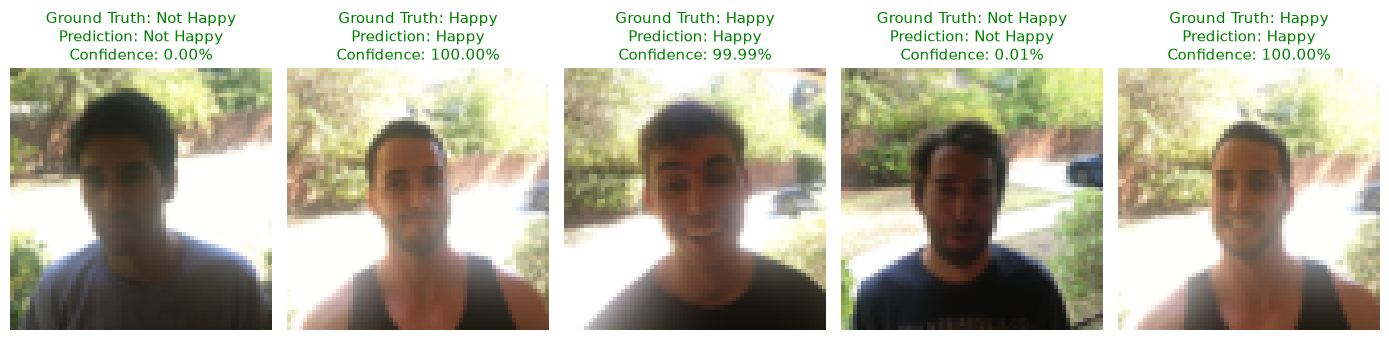

In [71]:
num_samples=5
random_indices = np.random.choice(X_test.shape[0], num_samples, replace=False)

plt.figure(figsize=(14, 5))

for i, idx in enumerate(random_indices):
    img = X_test[idx]
    true_label = int(Y_test[idx])
    img_for_prediction = np.expand_dims(img, axis=0)
    
    pred_prob=hmodel2.predict(img_for_prediction, verbose=0)[0][0]
    
    pred_label= 1 if pred_prob > 0.5 else 0

    status_true ="Happy" if true_label == 1 else "Not Happy"
    status_pred ="Happy" if pred_label == 1 else "Not Happy"
    
    title_color= 'green' if true_label == pred_label else 'red'

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    
    plt.title(f"Ground Truth: {status_true}\nPrediction: {status_pred}\nConfidence: {pred_prob:.2%}", 
              color=title_color, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Висновок

З отриманих результатів видно, що додавання додаткових шарів і Dropout дало змогу покращити якість моделі. Вона демонструє дуже високу впевненість у своїх прогнозах, а графіки втрат і точності показують, що перша модель схильна до перенавчання, тоді як друга поводиться стабільніше і краще узагальнює дані.